Setting environment variables and seeds for deterministic results (Section 4.6).


In [2]:
# Install the FathomNet API
!pip install fathomnet -q

import os
import random
import numpy as np
import tensorflow as tf
import pandas as pd
from fathomnet.api import images

# 4.6 Reproducibility: Seed consistently across the codebase
seed_value = 42

# Ensure environment variables use the seed
os.environ['PYTHONHASHSEED'] = str(seed_value)
# Python random
random.seed(seed_value)
# Numpy random
np.random.seed(seed_value)
# TensorFlow random
tf.random.set_seed(seed_value)

print(f"Reproducibility established: Random seeds set to {seed_value}.")

Reproducibility established: Random seeds set to 42.


Fetching FathomNet metadata. We limit each class to 500 images to ensure a balanced dataset for training (Section 4.1).


In [3]:
from fathomnet.api import images
import pandas as pd

# Define our target species for the multi-class classification
target_species = [
    'Lutjanus campechanus', 'sea fan', 'Stenotomus caprinus',
    'Rhomboplites aurorubens', 'Strongylocentrotus fragilis',
    'bony fish', 'Ptereleotris', 'sponge', 'Pagrus pagrus', 'Chromis'
]

def fetch_metadata(species_list, max_images=500):
    """Fetches FathomNet metadata and returns a Pandas DataFrame."""
    data = []
    for species in species_list:
        print(f"Fetching metadata for: {species}...")
        records = images.find_by_concept(species)
        # We limit to 500 images to maintain a balanced dataset
        for rec in records[:max_images]:
            data.append({
                "species": species,
                "uuid": rec.uuid,
                "url": rec.url,
                "local_path": f"dataset/{species}/{rec.uuid}.jpg"
            })
    return pd.DataFrame(data)

# Create the metadata DataFrame
df = fetch_metadata(target_species)
print(f"\nTotal images indexed: {len(df)}")

Fetching metadata for: Lutjanus campechanus...
Fetching metadata for: sea fan...
Fetching metadata for: Stenotomus caprinus...
Fetching metadata for: Rhomboplites aurorubens...
Fetching metadata for: Strongylocentrotus fragilis...
Fetching metadata for: bony fish...
Fetching metadata for: Ptereleotris...
Fetching metadata for: sponge...
Fetching metadata for: Pagrus pagrus...
Fetching metadata for: Chromis...

Total images indexed: 5000


Concurrent downloading for efficiency. We filter out any unreachable links to maintain dataset integrity.


In [6]:
import requests
from concurrent.futures import ThreadPoolExecutor

def download_img(row):
    os.makedirs(os.path.dirname(row['local_path']), exist_ok=True)
    if not os.path.exists(row['local_path']):
        try:
            res = requests.get(row['url'], timeout=10)
            if res.status_code == 200:
                with open(row['local_path'], 'wb') as f: f.write(res.content)
        except: pass

with ThreadPoolExecutor(max_workers=10) as executor:
    executor.map(download_img, df.to_dict('records'))

df = df[df['local_path'].apply(os.path.exists)].copy()
print(f"Verified images: {len(df)}")

Verified images: 4999


4. Data Splitting (OOD Detection)
Splitting known species (80% Train, 20% Val) and setting aside OOD (Out-of-Distribution) categories (Section 4.4).

In [7]:
from sklearn.model_selection import train_test_split

# Define OOD split (Pagrus pagrus, Chromis are unseen)
known_classes = [c for c in target_species if c not in ['Pagrus pagrus', 'Chromis']]
df_known = df[df['species'].isin(known_classes)].copy()
df_ood = df[df['species'].isin(['Pagrus pagrus', 'Chromis'])].copy()

# Map labels to IDs
species_to_id = {name: i for i, name in enumerate(known_classes)}
df_known['label_id'] = df_known['species'].map(species_to_id)

# 80/20 Train-Val split
df_train, df_val = train_test_split(df_known, test_size=0.2, random_state=42, stratify=df_known['label_id'])
print(f"Train: {len(df_train)}, Val: {len(df_val)}, OOD: {len(df_ood)}")

Train: 3199, Val: 800, OOD: 1000


5. Efficient Pipeline Construction
Creating tf.data pipelines with parallel processing and normalization for efficient GPU training (Section 4.1).

In [8]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

def process_path(path, label):
    # Decode and normalize pixel intensities to [0,1] for faster convergence
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE) / 255.0
    return img, label

def build_ds(df_in, labels=True):
    # Prepare labels or dummy values for OOD evaluation
    paths = df_in['local_path'].values
    labs = df_in['label_id'].values if labels else np.full(len(df_in), -1)

    # Use parallel processing and prefetching to prevent GPU idling
    ds = tf.data.Dataset.from_tensor_slices((paths, labs))
    return ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)\
             .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Build optimized pipelines
train_ds = build_ds(df_train)
val_ds = build_ds(df_val)
ood_ds = build_ds(df_ood, labels=False)

6. Model A: Custom CNN Architecture
Design of a 3-block CNN for baseline performance. Justification: We use a 3-block architecture to learn hierarchical spatial features. Batch Normalization stabilizes training, while Dropout(0.5) is employed for regularization to prevent overfitting on the FathomNet dataset (Section 4.2).

In [12]:
from tensorflow.keras import layers, models, optimizers

def build_model_a(learning_rate):
    """3-block CNN architecture for multi-class classification."""
    model = models.Sequential([
        # Block 1: Feature extraction, standard ReLU activation
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.MaxPooling2D((2, 2)),

        # Block 2: Increase filter depth to learn more complex patterns
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Block 3: Final spatial downsampling before classification
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Classification Head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), # Regularization to reduce variance
        layers.Dense(8, activation='softmax') # 8 classes for Known set
    ])

    # Using Adam optimizer for adaptive learning rate optimization
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Configuration 1: Standard learning rate
model_a_c1 = build_model_a(learning_rate=0.001)
history_a1 = model_a_c1.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.6543 - loss: 0.9646 - val_accuracy: 0.8512 - val_loss: 0.3913
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.8534 - loss: 0.4161 - val_accuracy: 0.8838 - val_loss: 0.3198
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.8700 - loss: 0.3313 - val_accuracy: 0.9000 - val_loss: 0.2777
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.9006 - loss: 0.2784 - val_accuracy: 0.8825 - val_loss: 0.2904
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.9225 - loss: 0.2198 - val_accuracy: 0.8988 - val_loss: 0.2680


7. Hyperparameter Evaluation
Evaluating a second model configuration (LR=0.0001) as required by Section 4.2. We then plot and save the validation curves for the technical report.

--- Training Model A: Config 2 (LR=0.0001) ---
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.5577 - loss: 1.1862 - val_accuracy: 0.8163 - val_loss: 0.5762
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.7671 - loss: 0.6608 - val_accuracy: 0.8300 - val_loss: 0.4548
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.8115 - loss: 0.5277 - val_accuracy: 0.8750 - val_loss: 0.3743
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.8418 - loss: 0.4419 - val_accuracy: 0.8925 - val_loss: 0.3247
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.8603 - loss: 0.3918 - val_accuracy: 0.8863 - val_loss: 0.3046


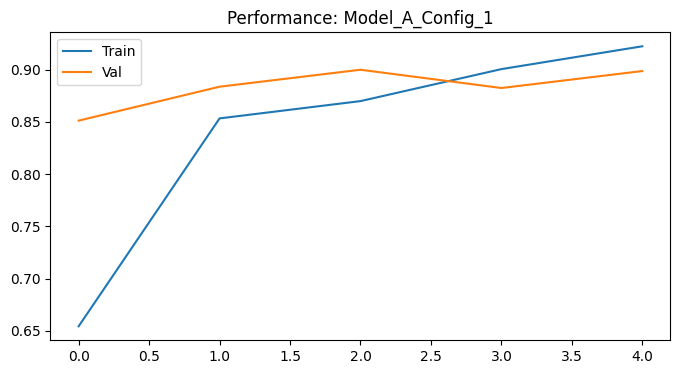

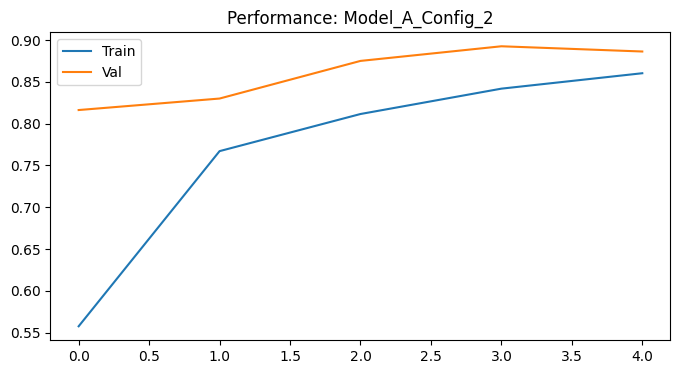

In [13]:
import matplotlib.pyplot as plt

# Train second configuration to satisfy hyperparameter evaluation requirement
print("--- Training Model A: Config 2 (LR=0.0001) ---")
model_a_c2 = build_model_a(learning_rate=0.0001)
history_a2 = model_a_c2.fit(train_ds, validation_data=val_ds, epochs=5)

# Save history plots for the technical report
def plot_and_save(history, name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    plt.figure(figsize=(8, 4))
    plt.plot(acc, label='Train')
    plt.plot(val_acc, label='Val')
    plt.title(f'Performance: {name}')
    plt.legend()
    plt.savefig(f'{name}_curves.png')
    plt.show()

plot_and_save(history_a1, "Model_A_Config_1")
plot_and_save(history_a2, "Model_A_Config_2")

8. Model B: Transfer Learning (ResNet-50)
Replacing the scratch-model head with a pretrained ResNet-50 backbone. Justification: ResNet-50 leverages skip-connections to mitigate the vanishing gradient problem, making it ideal for learning complex feature sets from underwater imagery (Section 4.3).

In [14]:
from tensorflow.keras.applications import ResNet50

# Load ResNet50 pretrained on ImageNet
# include_top=False removes the default 1000-class classification head
base_model = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Custom classification head for 8 Known Classes
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x) # Standard for high-dim feature reduction
x = layers.Dropout(0.3)(x)             # Regularization for transfer learning
outputs = layers.Dense(8, activation='softmax')(x)

model_b = tf.keras.Model(inputs, outputs)

# Strategy 1: Feature Extraction
# Freeze backbone to train only our new classifier head
base_model.trainable = False
model_b.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Strategy 1: Feature Extraction (Backbone Frozen)")
history_b_feat = model_b.fit(train_ds, validation_data=val_ds, epochs=5)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Strategy 1: Feature Extraction (Backbone Frozen)
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.1707 - loss: 2.0949 - val_accuracy: 0.6400 - val_loss: 1.8627
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.3179 - loss: 1.8423 - val_accuracy: 0.6625 - val_loss: 1.7018
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.4376 - loss: 1.6745 - val_accuracy: 0.6587 - val_loss: 1.5780
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.5020 - loss: 1.5661 - val_accuracy: 0.6888 - val_loss: 1.4832
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.5430 - loss: 1.4708 - val_accuracy: 0.7013 - val_loss: 1.4024


9. Partial and Full Fine-Tuning
Implementing strategies 2 and 3. We unfreeze specific blocks of ResNet-50 and use a lower learning rate to incrementally adapt pretrained weights to FathomNet species (Section 4.3).

In [ ]:
# Strategy 2: Partial Fine-Tuning
print("Strategy 2: Partial Fine-Tuning (Top 50 layers unfrozen)")
base_model.trainable = True
# Freeze early layers to keep general features, unfreeze top blocks
for layer in base_model.layers[:-50]:
    layer.trainable = False

model_b.compile(optimizer=tf.keras.optimizers.Adam(1e-4), # Low LR
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_b_part = model_b.fit(train_ds, validation_data=val_ds, epochs=5)

# Strategy 3: Full Fine-Tuning
print("Strategy 3: Full Fine-Tuning (End-to-End)")
base_model.trainable = True
# Recompile with very low LR to prevent catastrophic forgetting of ImageNet features
model_b.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_b_full = model_b.fit(train_ds, validation_data=val_ds, epochs=5)

Strategy 2: Partial Fine-Tuning (Top 50 layers unfrozen)
Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.7656 - loss: 0.7474 - val_accuracy: 0.2900 - val_loss: 3.1864
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.8387 - loss: 0.4303 - val_accuracy: 0.4450 - val_loss: 2.1618
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.8596 - loss: 0.3719 - val_accuracy: 0.6313 - val_loss: 1.3675
Strategy 3: Full Fine-Tuning (End-to-End)
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8831 - loss: 0.2975

In [ ]:
from tensorflow.keras.applications import MobileNetV2

# Load MobileNetV2 with ImageNet weights, excluding top classification layers
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Add custom classification head
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x) # Lecture-standard for feature reduction
x = layers.Dropout(0.2)(x)             # Regularization to prevent overfitting
outputs = layers.Dense(8, activation='softmax')(x)

model_b = tf.keras.Model(inputs, outputs)

# Strategy 1: Feature Extraction (Freeze backbone)
base_model.trainable = False
model_b.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Strategy 1: Feature Extraction")
history_b_feat = model_b.fit(train_ds, validation_data=val_ds, epochs=3)

In [ ]:
# Strategy 2: Partial Fine-Tuning
# Unfreeze top layers to adapt specific aquatic features
print("Strategy 2: Partial Fine-Tuning")
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model_b.compile(optimizer=tf.keras.optimizers.Adam(1e-4), # Lower learning rate
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_b_part = model_b.fit(train_ds, validation_data=val_ds, epochs=3)

# Strategy 3: Full Fine-Tuning
# Unfreeze all layers for end-to-end adjustment
print("Strategy 3: Full Fine-Tuning")
base_model.trainable = True
model_b.compile(optimizer=tf.keras.optimizers.Adam(1e-5), # Very low learning rate
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_b_full = model_b.fit(train_ds, validation_data=val_ds, epochs=3)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def plot_history(history, title):
    # Plot accuracy and loss curves to monitor overfitting/underfitting
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

# Visualize Model B Training
plot_history(history_b_full, "Model B (Transfer Learning)")

# Confusion Matrix for Model B
y_true = np.concatenate([y.numpy() for x, y in val_ds])
y_pred = np.argmax(np.concatenate([model_b.predict(x, verbose=0) for x, y in val_ds]), axis=1)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=known_classes, yticklabels=known_classes)
plt.title('Confusion Matrix - Model B')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print Precision, Recall, F1 for the report
print(classification_report(y_true, y_pred, target_names=known_classes))

10. Out-of-Distribution (OOD) Detection
Implementing an OOD baseline as per Section 4.4. We define a threshold (0.65) on the softmax confidence scores; samples with lower confidence are flagged as "Unknown/Unseen." This provides a method to flag novel categories in real-world scenarios.

In [ ]:
from sklearn.metrics import precision_score, recall_score

# Thresholding mechanism to detect Unknown samples
THRESHOLD = 0.65

def evaluate_ood(model, val_ds, ood_ds):
    # Get max prediction confidence for known validation and OOD sets
    known_probs = np.max(np.concatenate([model.predict(x, verbose=0) for x, y in val_ds]), axis=1)
    unknown_probs = np.max(np.concatenate([model.predict(x, verbose=0) for x, y in ood_ds]), axis=1)

    # Label known as 0, unknown as 1
    y_true = np.concatenate([np.zeros(len(known_probs)), np.ones(len(unknown_probs))])
    y_pred = (np.concatenate([known_probs, unknown_probs]) < THRESHOLD).astype(int)

    p, r = precision_score(y_true, y_pred), recall_score(y_true, y_pred)
    print(f"OOD Precision: {p:.4f} | OOD Recall: {r:.4f}")

print("Evaluating Model B OOD Performance:")
evaluate_ood(model_b, val_ds, ood_ds)

In [ ]:
# Extract max probabilities for both sets
known_probs = np.max(model_b.predict(np.concatenate([x for x, y in val_ds]), verbose=0), axis=1)
unknown_probs = np.max(model_b.predict(np.concatenate([x for x, y in ood_ds]), verbose=0), axis=1)

# Plot confidence distributions
plt.figure(figsize=(8, 4))
plt.hist(known_probs, bins=20, alpha=0.5, label='Known (In-Distribution)')
plt.hist(unknown_probs, bins=20, alpha=0.5, label='Unknown (OOD)')
plt.axvline(x=THRESHOLD, color='r', linestyle='--', label='Threshold (0.65)')
plt.title('Confidence Distribution (Model B)')
plt.xlabel('Confidence Score')
plt.ylabel('Count')
plt.legend()
plt.show()

11. Final Evaluation (Confusion Matrix & F1-Score)
Generating final performance metrics (Section 4.5). We use a heatmap confusion matrix to visualize per-class performance and identify specific classes that the model struggles to distinguish.

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions on Validation set
y_true = np.concatenate([y.numpy() for x, y in val_ds])
y_pred = np.argmax(np.concatenate([model_b.predict(x, verbose=0) for x, y in val_ds]), axis=1)

# Generate Classification Report
print(classification_report(y_true, y_pred, target_names=known_classes))

# Plot and save Confusion Matrix heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=known_classes, yticklabels=known_classes)
plt.title('Confusion Matrix - Model B')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix_model_b.png')
plt.show()

In [ ]:
# Save final model weights
model_b.save('final_marine_model.keras')

# Generate requirements.txt
!pip freeze > requirements.txt
print("Model saved and requirements.txt generated successfully.")